In [1]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor, Compose, Resize
from torch.utils.data import DataLoader
from DDPM_Net import *
from DDPM_GaussianDiffusion import *

class ImagePairDataset(Dataset):
    def __init__(self, noisy_dir, ground_truth_dir, transform=None):
        self.noisy_dir = noisy_dir
        self.ground_truth_dir = ground_truth_dir
        self.noisy_images = sorted(os.listdir(noisy_dir))
        self.ground_truth_images = sorted(os.listdir(ground_truth_dir))
        self.transform = transform

    def __len__(self):
        return len(self.noisy_images)

    def __getitem__(self, idx):
        noisy_path = os.path.join(self.noisy_dir, self.noisy_images[idx])
        ground_truth_path = os.path.join(self.ground_truth_dir, self.ground_truth_images[idx])
        
        noisy_image = Image.open(noisy_path).convert("L")
        ground_truth_image = Image.open(ground_truth_path).convert("L")
        
        if self.transform:
            noisy_image = self.transform(noisy_image)
            ground_truth_image = self.transform(ground_truth_image)
        
        return noisy_image, ground_truth_image

transform = Compose([
    Resize((512, 512)),
    ToTensor()
])

noisy_dir = r'C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\cropped_base_images'
ground_truth_dir = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\aligned_self_fused_images"
dataset = ImagePairDataset(noisy_dir, ground_truth_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)


c:\Users\CL-11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class GaussianDiffusion:
    def __init__(self, *, betas, device):
        self.device = device
        self.betas = betas.to(self.device)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def diffuse(self, x0, t):
        assert (t < self.betas.shape[0]).all(), "t values must be within the range of betas"
        
        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t).to(self.device)
            
        x0 = x0.to(self.device)
        eps = torch.randn_like(x0).to(self.device)
        alpha_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)
        
        xt = torch.sqrt(alpha_cumprod_t) * x0 + torch.sqrt(1 - alpha_cumprod_t) * eps
        
        return xt
    
    def denoise(self, xt, eps, t):
        assert xt.shape == eps.shape
        
        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t).to(self.device)
        
        xt = xt.to(self.device)
        alpha_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)
        
        x0_pred = 1 / torch.sqrt(alpha_cumprod_t) * xt - torch.sqrt(1 - alpha_cumprod_t) / torch.sqrt(alpha_cumprod_t) * eps 
        
        return x0_pred
    
    def dist_compare(self, xt, eps, t):
        assert xt.shape == eps.shape
        
        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t).to(self.device)
        
        xt = xt.to(self.device)
        alpha_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)
        
        target = 1 / torch.sqrt(alpha_cumprod_t) * xt 
        predict = torch.sqrt(1 - alpha_cumprod_t) / torch.sqrt(alpha_cumprod_t) * eps 
        
        return target, predict
    
    def reverse(self, xt, eps, t):
        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t).to(self.device)
        
        beta_t = self.betas[t].view(-1, 1, 1, 1)
        alpha_t = self.alphas[t].view(-1, 1, 1, 1)
        alpha_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)
        alpha_cumprod_prev = self.alphas_cumprod[t - 1].view(-1, 1, 1, 1)
        
        c1 = torch.sqrt(alpha_cumprod_prev) * beta_t / (1 - alpha_cumprod_prev)
        c2 = torch.sqrt(alpha_t) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod_t)
        
        x0_pred = self.denoise(xt, eps, t)
        x_prev = c1 * x0_pred + c2 * xt
        
        return x_prev
    
    @staticmethod
    def _to_nparray_(x, *, rescale=True, transpose=True):
        x = x[0, 0, :, :].detach().cpu().numpy()
        if transpose:
            x = np.transpose(x)
        if rescale:
            x = util.ImageRescale(x, [0, 255])
        return x[:,:500]

def get_beta_schedule(beta_schedule, *, beta_start, beta_end, num_diffusion_timesteps):
    def sigmoid(x):
        return 1 / (np.exp(-x) + 1)

    if beta_schedule == "quad":
        betas = (
            np.linspace(
                beta_start ** 0.5,
                beta_end ** 0.5,
                num_diffusion_timesteps,
                dtype=np.float64,
            )
            ** 2
        )
    elif beta_schedule == "linear":
        betas = np.linspace(
            beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64
        )
    elif beta_schedule == "const":
        betas = beta_end * np.ones(num_diffusion_timesteps, dtype=np.float64)
    elif beta_schedule == "jsd":  # 1/T, 1/(T-1), 1/(T-2), ..., 1
        betas = 1.0 / np.linspace(
            num_diffusion_timesteps, 1, num_diffusion_timesteps, dtype=np.float64
        )
    elif beta_schedule == "sigmoid":
        betas = np.linspace(-6, 6, num_diffusion_timesteps)
        betas = sigmoid(betas) * (beta_end - beta_start) + beta_start
    else:
        raise NotImplementedError(beta_schedule)
    assert betas.shape == (num_diffusion_timesteps,)
    return betas


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Assuming you have imported your DDPM model and GaussianDiffusion class correctly
# from DDPM_Net import Model
# from DDPM_GaussianDiffusion import GaussianDiffusion, get_beta_schedule

# Initialize the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Load GaussianDiffusion instance
T = 100
betas = get_beta_schedule('linear', beta_start=0.0001, beta_end=0.02, num_diffusion_timesteps=T)
betas = torch.from_numpy(betas).float().to(device)
diffusion = GaussianDiffusion(betas=betas, device=device)

try:
    # get last epoch
    checkpoint = torch.load("../ckpts/checkpoint_epoch_last.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    print(f"Loaded checkpoint from epoch {epoch} with loss {loss}")
except:
    print("Failed to load checkpoint")

# Fine-tuning loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (noisy, ground_truth) in enumerate(dataloader):
        noisy = noisy.to(device)
        ground_truth = ground_truth.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass through the model and the diffusion process
        t = torch.randint(0, T, (noisy.size(0),), device=device).long()
        noisy = diffusion.diffuse(noisy, t)
        eps = torch.randn_like(noisy)
        output = model(noisy, t.float())
        
        loss = criterion(output, ground_truth)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 10 == 9:
            print(f"[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 10}")
            running_loss = 0.0

        # save every 10 epochs
        if i % 10 == 9:
            try:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': loss,
                }, f"../ckpts/checkpoint_epoch_{epoch}.pth")
            except:
                print("Failed to save checkpoint")

        try:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss,
            }, f"../ckpts/checkpoint_epoch_last.pth")
        except:
            print("Failed to save checkpoint")

print("Finished Fine-tuning")


Failed to load checkpoint
[Epoch 1, Batch 10] Loss: 0.29569573402404786
[Epoch 1, Batch 20] Loss: 0.16441863775253296
[Epoch 1, Batch 30] Loss: 0.10595022141933441
[Epoch 1, Batch 40] Loss: 0.06905097365379334
[Epoch 1, Batch 50] Loss: 0.045371605828404424
[Epoch 1, Batch 60] Loss: 0.03809547424316406
[Epoch 1, Batch 70] Loss: 0.027290773764252662
[Epoch 1, Batch 80] Loss: 0.02010539676994085
[Epoch 1, Batch 90] Loss: 0.017671860475093126
[Epoch 1, Batch 100] Loss: 0.01451527774333954
[Epoch 1, Batch 110] Loss: 0.015332717169076204
[Epoch 1, Batch 120] Loss: 0.01489488985389471
[Epoch 1, Batch 130] Loss: 0.011547745577991009
[Epoch 1, Batch 140] Loss: 0.011741953622549772
[Epoch 1, Batch 150] Loss: 0.010172405000776052
[Epoch 1, Batch 160] Loss: 0.00908689210191369
[Epoch 1, Batch 170] Loss: 0.009348019771277905
[Epoch 2, Batch 10] Loss: 0.008630914753302932
[Epoch 2, Batch 20] Loss: 0.008045722218230366
[Epoch 2, Batch 30] Loss: 0.007233399897813797
[Epoch 2, Batch 40] Loss: 0.0071746

KeyboardInterrupt: 

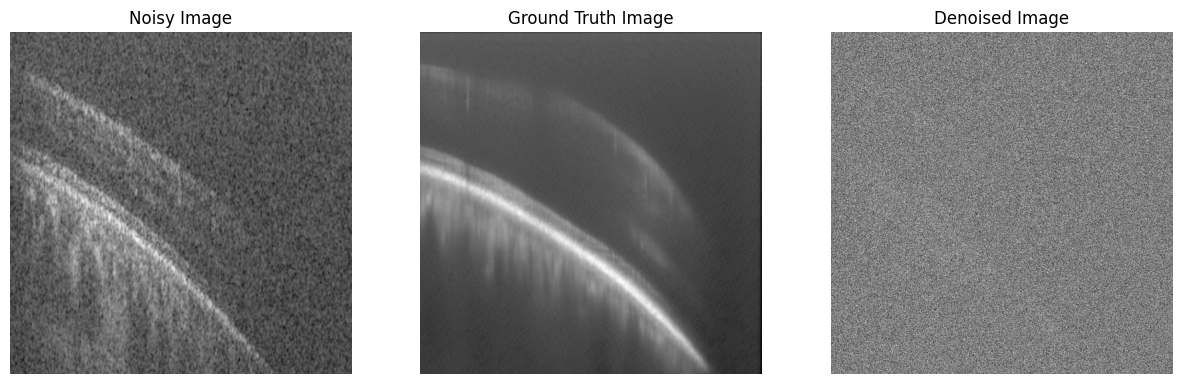

In [7]:
# Load one image from your dataset
noisy_image_path = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\cropped_base_images\RawDataQA3 (14).tiff"
ground_truth_image_path = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\aligned_self_fused_images\RawDataQA3 (14).tiff"

transform = Compose([
    Resize((512, 512)),
    ToTensor()
])

noisy_image = Image.open(noisy_image_path).convert("L")
ground_truth_image = Image.open(ground_truth_image_path).convert("L")

noisy_image = transform(noisy_image).unsqueeze(0)  # Add batch dimension
ground_truth_image = transform(ground_truth_image).unsqueeze(0)  # Add batch dimension

# Define the device and load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)
checkpoint = torch.load("../ckpts/checkpoint_epoch_1.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Define the diffusion parameters
T = 100
betas = np.linspace(0.0001, 0.02, T)
betas = torch.from_numpy(betas).float().to(device)
diffusion = GaussianDiffusion(betas=betas, device=device)

# Forward pass through the model and the diffusion process
t = torch.randint(0, T, (noisy_image.size(0),), device=device).long()
noisy_diffused = diffusion.diffuse(noisy_image, t)
eps = torch.randn_like(noisy_diffused)
output = model(noisy_diffused, t.float())

# Denoise the image
denoised_image = diffusion.denoise(noisy_diffused, eps, t)

import matplotlib.pyplot as plt

# Plot the images
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(noisy_image[0].squeeze().cpu().numpy(), cmap='gray')
axs[0].set_title('Noisy Image')
axs[0].axis('off')

axs[1].imshow(ground_truth_image[0].squeeze().cpu().numpy(), cmap='gray')
axs[1].set_title('Ground Truth Image')
axs[1].axis('off')

axs[2].imshow(denoised_image[0].squeeze().cpu().numpy(), cmap='gray')
axs[2].set_title('Denoised Image')
axs[2].axis('off')

plt.show()

In [8]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Compose, Resize
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random

# Define custom Dataset class for image pairs
class ImagePairDataset(Dataset):
    def __init__(self, noisy_dir, ground_truth_dir, transform=None):
        self.noisy_dir = noisy_dir
        self.ground_truth_dir = ground_truth_dir
        self.noisy_images = sorted(os.listdir(noisy_dir))
        self.ground_truth_images = sorted(os.listdir(ground_truth_dir))
        self.transform = transform

    def __len__(self):
        return len(self.noisy_images)

    def __getitem__(self, idx):
        noisy_path = os.path.join(self.noisy_dir, self.noisy_images[idx])
        ground_truth_path = os.path.join(self.ground_truth_dir, self.ground_truth_images[idx])
        
        noisy_image = Image.open(noisy_path).convert("L")
        ground_truth_image = Image.open(ground_truth_path).convert("L")
        
        if self.transform:
            noisy_image = self.transform(noisy_image)
            ground_truth_image = self.transform(ground_truth_image)
        
        return noisy_image, ground_truth_image

# Transform for images
transform = Compose([
    Resize((512, 512)),
    ToTensor()
])

# Dataset paths
noisy_dir = r'C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\cropped_base_images'
ground_truth_dir = r"C:\Users\CL-11\OneDrive\Research\OCT_Image_Rego_Denoising\outputs\RawDataQA (3)\aligned_self_fused_images"

# Create the dataset and dataloader
dataset = ImagePairDataset(noisy_dir, ground_truth_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Load model and diffusion classes
from DDPM_Net import Model
from DDPM_GaussianDiffusion import GaussianDiffusion, get_beta_schedule

def noise_estimation_loss(model, x0, t, e, b, device):
    a = torch.cumprod(1-b, dim=0).index_select(0, t).view(-1, 1, 1, 1).to(device)
    x = x0 * a.sqrt() + e * (1.0 - a).sqrt()
    output = model(x, t.float())
    return (e - output).square().sum(dim=(1, 2, 3)).mean(dim=0)

def model_predict(model, x0, betas, t, T, device):
    with torch.no_grad():
        a = torch.cumprod(1 - betas, dim=0)
        a_t = a[t].to(device)
        e = torch.randn_like(x0).to(device)
        xt = torch.sqrt(1 - a_t) * e + torch.sqrt(a_t) * x0
        pred_e = model(xt, torch.tensor([T], device=device).float())
        x0_pred = 1 / torch.sqrt(a_t) * xt - torch.sqrt(1 - a_t) / torch.sqrt(a_t) * pred_e
        return x0_pred, xt

# Initialize the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

# Load pre-trained model if available
checkpoint_path = "path_to/DDPM_oct_dataset2_2021-07-08.pt"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded pre-trained model from {checkpoint_path}")

# Set up diffusion parameters
T = 100
betas = get_beta_schedule('linear', beta_start=0.0001, beta_end=0.02, num_diffusion_timesteps=T)
betas = torch.from_numpy(betas).float().to(device)
diffusion = GaussianDiffusion(betas=betas, device=device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

# Fine-tuning loop
n_epoch = 50
save_interval = 10  # Save checkpoint every 10 epochs
output_dir = "path_to_save_checkpoints"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0
    with tqdm(total=len(dataloader), desc=f"Epoch {epoch + 1}/{n_epoch}") as pbar:
        for step, (noisy, ground_truth) in enumerate(dataloader):
            noisy = noisy.to(device)
            ground_truth = ground_truth.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass through the model and the diffusion process
            n = noisy.size(0)
            t = torch.randint(0, T, (n,), device=device).long()
            e = torch.randn_like(noisy).to(device)
            loss = noise_estimation_loss(model, noisy, t, e, betas, device)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix(loss=running_loss / (step + 1))
            pbar.update(1)

            if step % (len(dataloader) - 1) == 0 and step != 0:
                timestep = random.randint(1, T-1)
                x0_pred, xt = model_predict(model, noisy, betas, timestep, T, device)
                
                plt.figure(figsize=(15, 6))
                plt.subplot(1, 3, 1)
                plt.imshow(noisy[0, 0].cpu().numpy(), cmap='gray')
                plt.axis('off')
                plt.title('Noisy Image')
                
                plt.subplot(1, 3, 2)
                plt.imshow(x0_pred[0, 0].cpu().numpy(), cmap='gray')
                plt.axis('off')
                plt.title('Predicted Image')
                
                plt.subplot(1, 3, 3)
                plt.imshow(xt[0, 0].cpu().numpy(), cmap='gray')
                plt.axis('off')
                plt.title(f't = {timestep}')
                
                plt.show()
    
    # Save checkpoint
    if (epoch + 1) % save_interval == 0:
        checkpoint_name = f"DDPM_finetuned_epoch_{epoch + 1}.pt"
        checkpoint_path = os.path.join(output_dir, checkpoint_name)
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")
    scheduler.step()

# Save the final model
final_model_path = os.path.join(output_dir, "DDPM_finetuned_final.pt")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved: {final_model_path}")

Epoch 1/50:   0%|          | 0/89 [00:00<?, ?it/s]c:\Users\CL-11\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
Epoch 1/50:   7%|▋         | 6/89 [00:30<06:57,  5.03s/it, loss=2.37e+5]